In [1]:
# ==============================
# Step 0 – Load libraries
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")


# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import os
print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\thebi\Documents\Master DA. UNF\Case Study 2\Part II Project\Group_1_CaseStudy2


### Mini-summary for Step 0

In this step, the main Python libraries required for the project were loaded.  
These packages include tools for data handling, visualization, and statistical analysis, which will be used throughout the exploratory and regression stages of the workflow.

All imports were executed successfully, and the random seed was set to 42 to ensure reproducibility of the results when running statistical models.

At this point, the notebook environment is correctly configured and ready for loading the dataset in the next step.

## STEP 1 – Load dataset and inspect structure

In [3]:
# ==============================
# Step 1 – Load dataset and inspect structure
# ==============================

file_name = "Ontario_dropout_dataset_updated.xlsx"

# Load dataset
df = pd.read_excel(file_name)

# Basic confirmation
print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

# Preview
print("\nFirst 5 rows:")
display(df.head())

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types
print("\nData types:")
display(df.dtypes)

print("\nDataset info:")
df.info()

# Check missing values
print("\nMissing values per column:")
display(df.isna().sum())

# Check duplicates
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

Dataset loaded successfully.
Shape of dataset: (5, 13)

First 5 rows:


,year,GEO_x,dropout_total_rate,median_income,low_income_rate,youth_unemployment_rate,funding_per_student,Demographic_total_15_19,attendance_rate_15_19,pct_adults_no_hs_diploma,policy_reform_dummy,spending_shift_dummy,secondary_avg_class_size
0,2018,Ontario,17.0,59507,17.68,15.45,14854,844382,61,7,0,1,22
1,2019,Ontario,14.0,61087,18.46,14.91,14672,844994,60,7,0,0,28
2,2020,Ontario,15.0,66380,14.67,25.44,13983,840767,61,6,0,0,23
3,2021,Ontario,13.0,66877,15.66,18.80,15034,824719,61,6,1,1,23
4,2022,Ontario,12.1,68263,17.53,13.98,15728,856254,63,6,1,1,23



Column names:
['year', 'GEO_x', 'dropout_total_rate', 'median_income', 'low_income_rate', 'youth_unemployment_rate', 'funding_per_student', 'Demographic_total_15_19', 'attendance_rate_15_19', 'pct_adults_no_hs_diploma', 'policy_reform_dummy', 'spending_shift_dummy', 'secondary_avg_class_size']

Data types:


year                          int64
GEO_x                        object
dropout_total_rate          float64
median_income                 int64
low_income_rate             float64
youth_unemployment_rate     float64
funding_per_student           int64
Demographic_total_15_19       int64
attendance_rate_15_19         int64
pct_adults_no_hs_diploma      int64
policy_reform_dummy           int64
spending_shift_dummy          int64
secondary_avg_class_size      int64
dtype: object


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      5 non-null      int64  
 1   GEO_x                     5 non-null      object 
 2   dropout_total_rate        5 non-null      float64
 3   median_income             5 non-null      int64  
 4   low_income_rate           5 non-null      float64
 5   youth_unemployment_rate   5 non-null      float64
 6   funding_per_student       5 non-null      int64  
 7   Demographic_total_15_19   5 non-null      int64  
 8   attendance_rate_15_19     5 non-null      int64  
 9   pct_adults_no_hs_diploma  5 non-null      int64  
 10  policy_reform_dummy       5 non-null      int64  
 11  spending_shift_dummy      5 non-null      int64  
 12  secondary_avg_class_size  5 non-null      int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 652.0

year                        0
GEO_x                       0
dropout_total_rate          0
median_income               0
low_income_rate             0
youth_unemployment_rate     0
funding_per_student         0
Demographic_total_15_19     0
attendance_rate_15_19       0
pct_adults_no_hs_diploma    0
policy_reform_dummy         0
spending_shift_dummy        0
secondary_avg_class_size    0
dtype: int64


Number of duplicate rows: 0


### Mini-summary for Step 1

In this step, the working dataset was loaded and its structure was inspected to confirm that the file was read correctly. The output shows that the dataset contains a small number of yearly observations with several economic, social, and policy-related variables.

Most variables were correctly interpreted as numeric, which is appropriate for statistical analysis. The inspection of column names, data types, and missing values confirms that the dataset is clean and ready for exploratory analysis.

At this point, the data loading step was successful, and the notebook is ready to proceed with descriptive statistics and trend analysis.

## STEP2 Select variables for analysis

In [4]:
# ==============================
# Step 2 – Select variables for analysis
# ==============================

# Keep year separately for trend analysis
time_var = "year"

# Outcome and explanatory variables
analysis_vars = [
    "dropout_total_rate",
    "median_income",
    "low_income_rate",
    "youth_unemployment_rate",
    "funding_per_student",
    "policy_reform_dummy",
    "spending_shift_dummy",
    "secondary_avg_class_size",
    "Demographic_total_15_19",
    "attendance_rate_15_19",
    "pct_adults_no_hs_diploma"
]

# Create analysis dataset
df_analysis = df[analysis_vars].copy()

# Optional: dataset for trend plots
df_trend = df[[time_var] + analysis_vars].copy()

# Confirm selection
print("Analysis dataset created successfully.")
print("Shape of analysis dataset:", df_analysis.shape)

print("\nVariables included in df_analysis:")
print(df_analysis.columns.tolist())

print("\nPreview of analysis dataset:")
display(df_analysis.head())

Analysis dataset created successfully.
Shape of analysis dataset: (5, 11)

Variables included in df_analysis:
['dropout_total_rate', 'median_income', 'low_income_rate', 'youth_unemployment_rate', 'funding_per_student', 'policy_reform_dummy', 'spending_shift_dummy', 'secondary_avg_class_size', 'Demographic_total_15_19', 'attendance_rate_15_19', 'pct_adults_no_hs_diploma']

Preview of analysis dataset:


,dropout_total_rate,median_income,low_income_rate,youth_unemployment_rate,funding_per_student,policy_reform_dummy,spending_shift_dummy,secondary_avg_class_size,Demographic_total_15_19,attendance_rate_15_19,pct_adults_no_hs_diploma
0,17.0,59507,17.68,15.45,14854,0,1,22,844382,61,7
1,14.0,61087,18.46,14.91,14672,0,0,28,844994,60,7
2,15.0,66380,14.67,25.44,13983,0,0,23,840767,61,6
3,13.0,66877,15.66,18.80,15034,1,1,23,824719,61,6
4,12.1,68263,17.53,13.98,15728,1,1,23,856254,63,6


### Mini-summary for Step 2

In this step, the dataset was restricted to the variables that are relevant for the analysis. The geographic column was excluded because all observations refer to Ontario, and therefore it does not add variation to the study. The year variable was retained separately for trend analysis, but it was not included in the analytical subset used for descriptive statistics and modelling.

The final analytical dataset now contains the dependent variable and the selected political, economic, and social indicators that will support the next stages of the project.

# STEP 3 – Descriptive statistics

In [5]:
# ==============================
# Step 3 – Descriptive statistics
# ==============================

desc_stats = df_analysis.describe().T

desc_stats = desc_stats[["mean", "std", "min", "max"]]

desc_stats = desc_stats.round(2)

print("Descriptive statistics summary:\n")
display(desc_stats)

Descriptive statistics summary:



,mean,std,min,max
dropout_total_rate,14.22,1.90,12.10,17.00
median_income,64422.80,3869.55,59507.00,68263.00
low_income_rate,16.80,1.57,14.67,18.46
youth_unemployment_rate,17.72,4.69,13.98,25.44
funding_per_student,14854.20,630.09,13983.00,15728.00
policy_reform_dummy,0.40,0.55,0.00,1.00
spending_shift_dummy,0.60,0.55,0.00,1.00
secondary_avg_class_size,23.80,2.39,22.00,28.00
Demographic_total_15_19,842223.20,11376.72,824719.00,856254.00
attendance_rate_15_19,61.20,1.10,60.00,63.00


In [6]:
print("\nRange of each variable:\n")

for col in df_analysis.columns:
    print(f"{col}: min={df_analysis[col].min()} | max={df_analysis[col].max()}")


Range of each variable:

dropout_total_rate: min=12.1 | max=17.0
median_income: min=59507 | max=68263
low_income_rate: min=14.67 | max=18.46
youth_unemployment_rate: min=13.98 | max=25.44
funding_per_student: min=13983 | max=15728
policy_reform_dummy: min=0 | max=1
spending_shift_dummy: min=0 | max=1
secondary_avg_class_size: min=22 | max=28
Demographic_total_15_19: min=824719 | max=856254
attendance_rate_15_19: min=60 | max=63
pct_adults_no_hs_diploma: min=6 | max=7


### Mini-summary for Step 3

Descriptive statistics were computed to examine the distribution and variability of the main variables included in the analysis. The results show that all variables fall within reasonable ranges and no abnormal values were detected.

Economic indicators such as median income and youth unemployment rate show moderate variation across years, while social indicators such as attendance rate and percentage of adults without high school diploma remain relatively stable. Political variables, including funding per student and average class size, show noticeable changes over time, reflecting policy adjustments during the study period.

The dummy variables for policy reform and spending shift correctly take values of 0 and 1, confirming that they were defined properly. Overall, the dataset appears consistent and suitable for further trend analysis and exploratory statistical modelling.

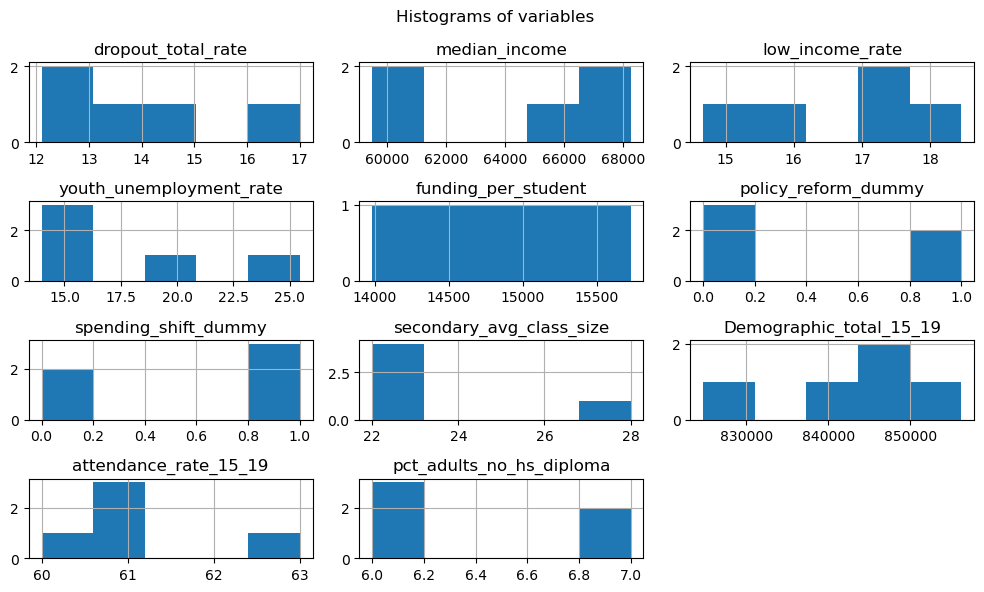

In [7]:
df_analysis.hist(figsize=(10,6), bins=5)

plt.suptitle("Histograms of variables")

plt.tight_layout()

plt.show()

### Mini-summary for Histograms

Descriptive statistics were computed to examine the distribution and variability of the main variables. Given the very small number of yearly observations, histogram visualizations were generated only for completeness, but they provide limited information. 

Even so, these plots remain useful as an initial exploratory step. They help verify the approximate range of values, confirm the measurement scale of each variable, and detect any obvious data entry issues or unusual patterns before moving to more substantive analysis.

Given the short time span of the dataset, distribution-based graphs are less informative than time-based visualizations. For this reason, the next step focuses on temporal patterns and the relationships between variables across years.

# STEP 4 Trend Analysis

In [8]:
# Trend-analysis dataframe
df_trend = df.sort_values("year").copy()

### Step 4.1 — Line plots for numeric variables

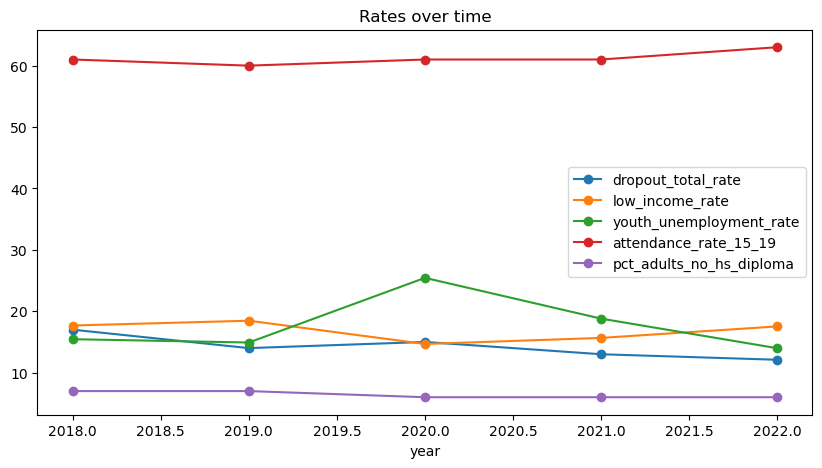

In [9]:
cols_rates = [
    "dropout_total_rate",
    "low_income_rate",
    "youth_unemployment_rate",
    "attendance_rate_15_19",
    "pct_adults_no_hs_diploma"
]

df_trend.set_index("year")[cols_rates].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Rates over time")
plt.show()

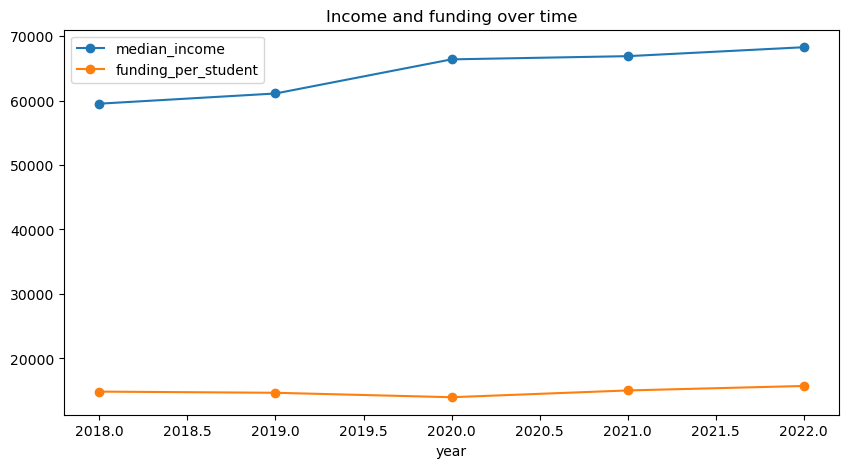

In [10]:
cols_money = [
    "median_income",
    "funding_per_student"
]

df_trend.set_index("year")[cols_money].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Income and funding over time")
plt.show()

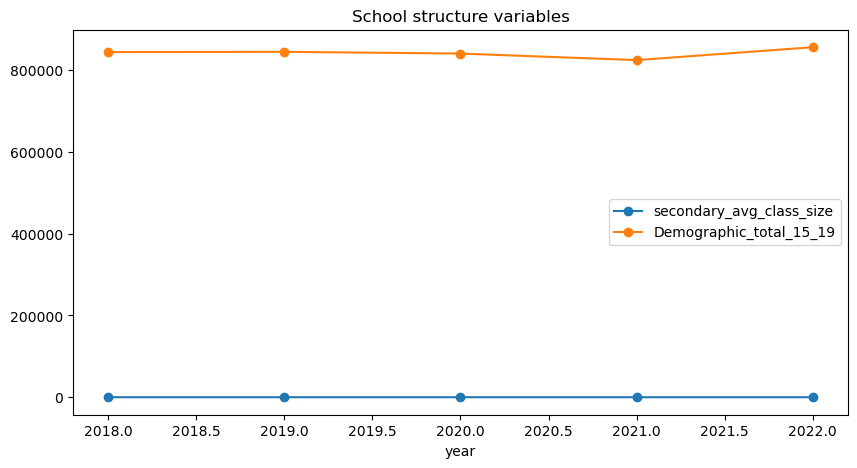

In [11]:
cols_school = [
    "secondary_avg_class_size",
    "Demographic_total_15_19"
]

df_trend.set_index("year")[cols_school].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("School structure variables")
plt.show()

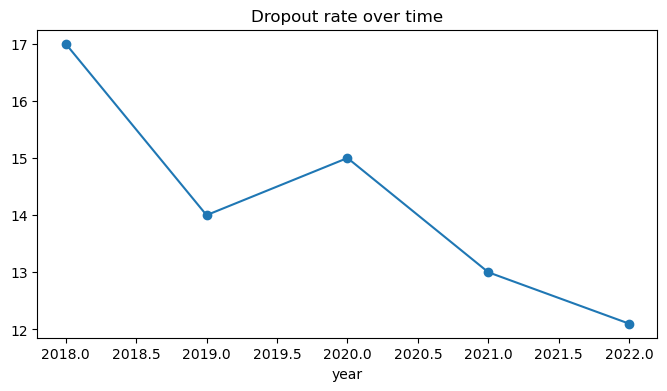

In [12]:
df_trend.set_index("year")["dropout_total_rate"].plot(
    marker="o",
    figsize=(8, 4)
)

plt.title("Dropout rate over time")
plt.show()

### Step 4.2 — Plot policy variables (dummy)

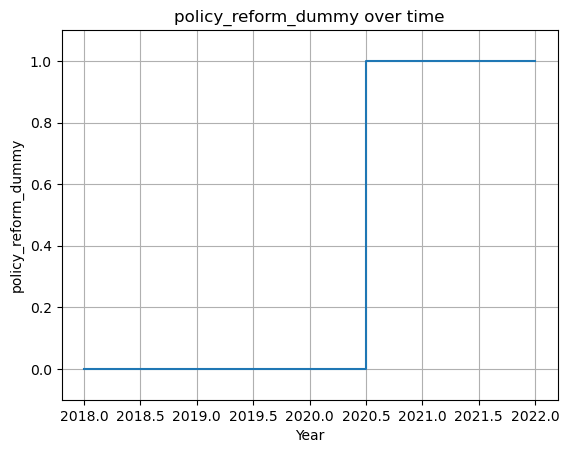

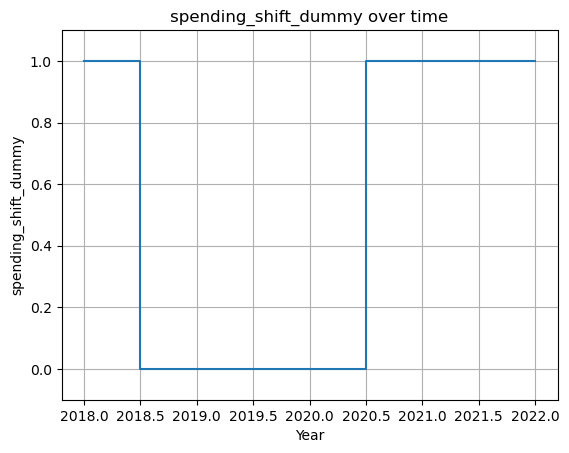

In [13]:
dummy_cols = [
    "policy_reform_dummy",
    "spending_shift_dummy"
]

for col in dummy_cols:
    plt.figure()
    plt.step(df["year"], df[col], where="mid")
    plt.title(f"{col} over time")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.show()

### Step 4.3 — Plot outcome vs policy

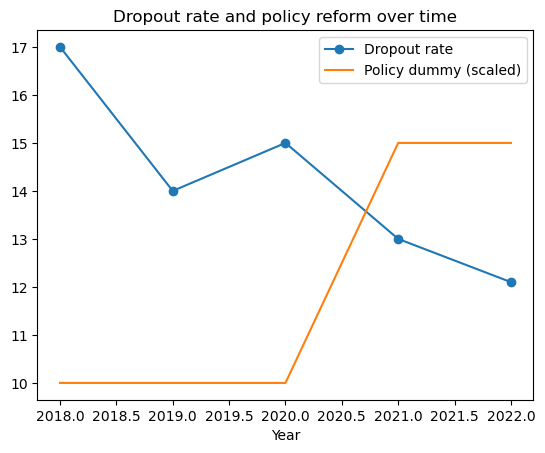

In [14]:
plt.figure()
plt.plot(df_trend["year"], df_trend["dropout_total_rate"], marker="o", label="Dropout rate")
plt.plot(df_trend["year"], df_trend["policy_reform_dummy"] * 5 + 10, label="Policy dummy (scaled)")

plt.legend()
plt.title("Dropout rate and policy reform over time")
plt.xlabel("Year")
plt.show()

### Mini-summary for Step 4 — Trend Analysis

Trend analysis was conducted using line plots to visualize how the variables evolved over the 2018–2022 period. Because the dataset represents a short annual time series, these plots provide more meaningful insight than distribution-based graphs.

Numeric variables were first examined by grouping them according to their measurement scale. The plots show that the dropout rate follows a gradual downward trend after 2020, while youth unemployment exhibits a temporary spike in the same year. Median income and funding per student show a generally increasing pattern, suggesting improving economic conditions and higher investment in the education system over time. Demographic variables remain relatively stable, indicating that cohort size alone does not explain the variation in dropout rates.

Policy dummy variables were then plotted to identify the timing of structural changes. The reform indicator switches from 0 to 1 after 2020, marking the period in which the policy change is assumed to take effect. The spending shift variable shows a similar change, suggesting a possible adjustment in resource allocation.

Finally, the dropout rate was plotted together with the policy dummy to visually inspect whether the change in policy coincides with changes in the outcome. The graph shows that the decline in dropout rates occurs after the policy indicator turns on, which is consistent with the expected direction of the hypothesis, although no causal conclusion can be drawn due to the small number of observations.

Overall, the trend analysis suggests that the decrease in dropout rates after 2020 may be associated with changes in economic conditions, funding levels, and policy interventions. These relationships will be examined more formally in the regression analysis.

# STEP 5 Basic Statistical Analysis

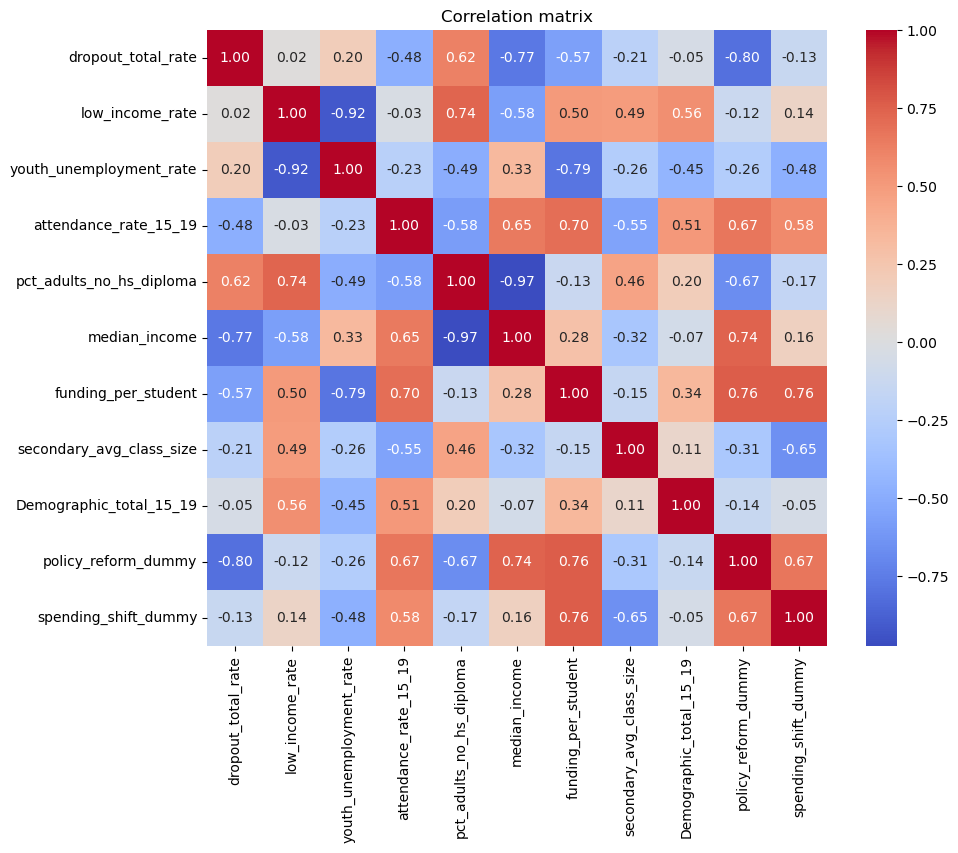

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_corr = [
    "dropout_total_rate",
    "low_income_rate",
    "youth_unemployment_rate",
    "attendance_rate_15_19",
    "pct_adults_no_hs_diploma",
    "median_income",
    "funding_per_student",
    "secondary_avg_class_size",
    "Demographic_total_15_19",
    "policy_reform_dummy",
    "spending_shift_dummy"
]

corr = df_analysis[cols_corr].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation matrix")
plt.show()

### Mini-summary for Step 5.1 — Correlation analysis

A correlation matrix was computed to examine the linear relationships between dropout rates and the main economic, demographic, school, and policy variables. Since the dataset contains only five yearly observations, the results must be interpreted with caution and should be considered descriptive rather than statistically conclusive.

The matrix suggests that dropout rates tend to decrease when median income and funding per student increase, and tend to be higher when socio-economic disadvantage indicators are stronger. Policy variables also show noticeable associations with dropout, although the limited number of observations prevents strong conclusions.

Several explanatory variables are highly correlated with each other, particularly among economic indicators, indicating potential multicollinearity that should be taken into account in the regression analysis.

Overall, the correlation matrix provides a preliminary view of the relationships in the data and helps guide the selection of variables for the statistical models in the next step.

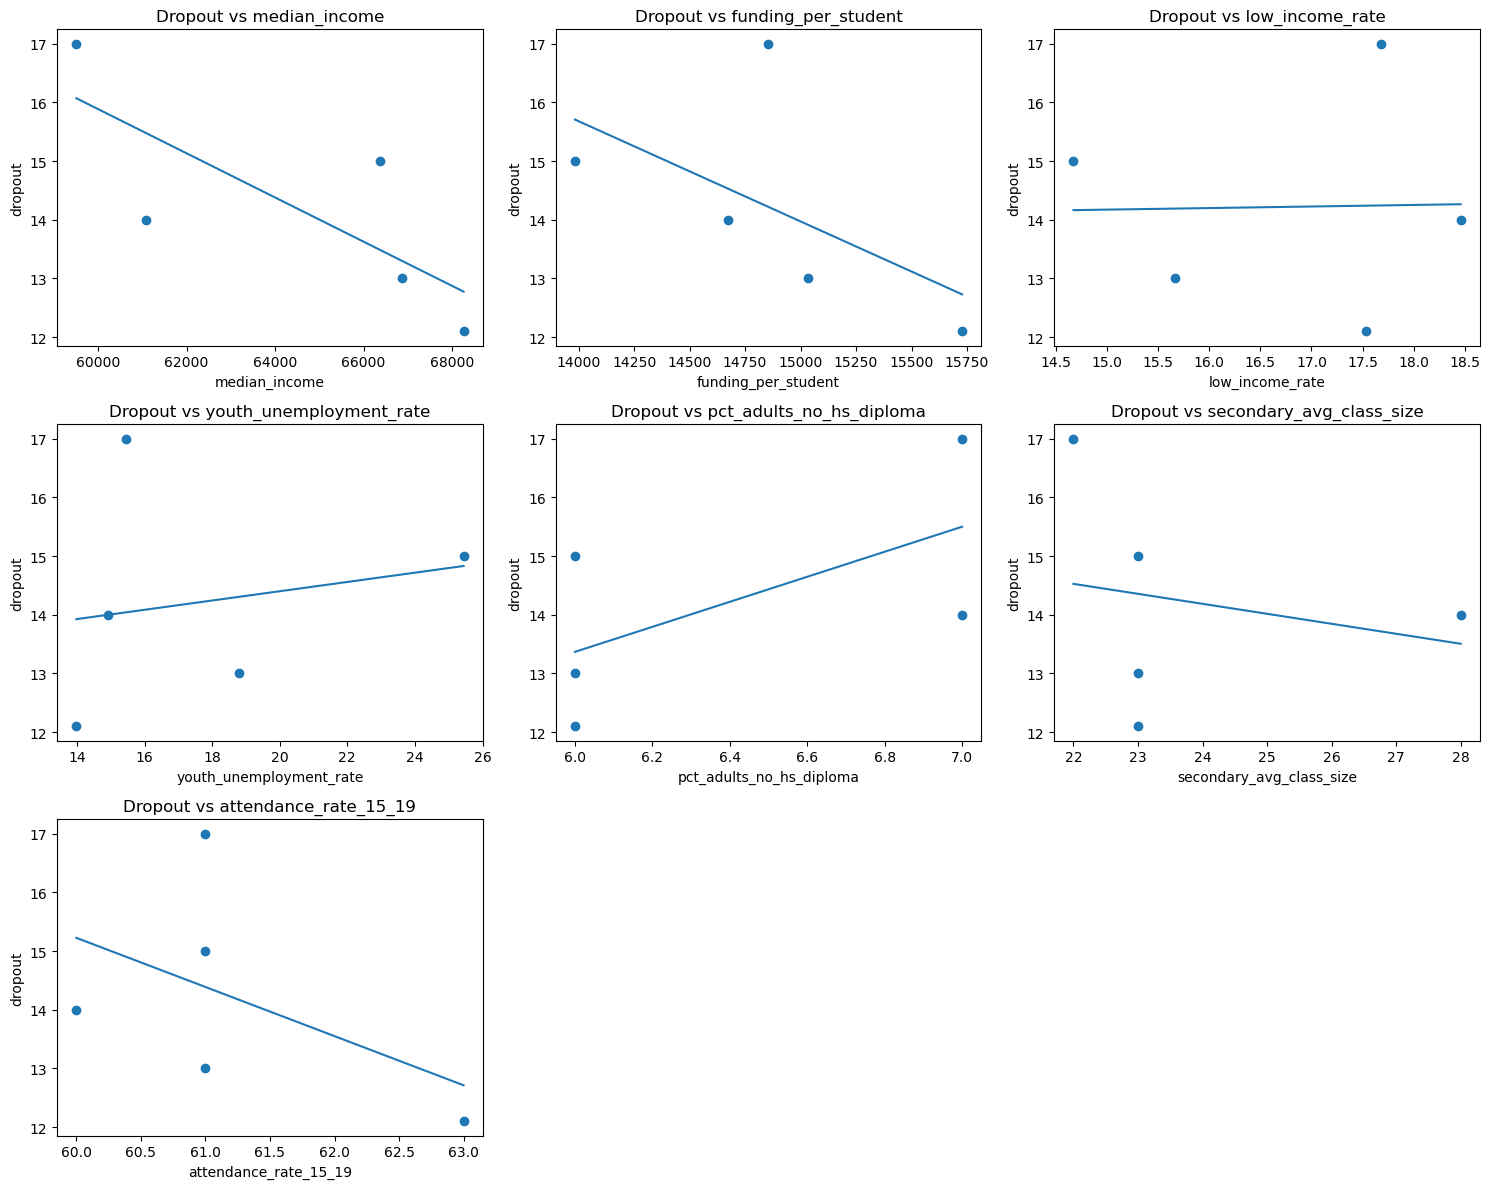

In [16]:
import matplotlib.pyplot as plt
import numpy as np

vars_scatter = [
    "median_income",
    "funding_per_student",
    "low_income_rate",
    "youth_unemployment_rate",
    "pct_adults_no_hs_diploma",
    "secondary_avg_class_size",
    "attendance_rate_15_19"
]

cols = 3
rows = int(np.ceil(len(vars_scatter) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))

axes = axes.flatten()

for i, col in enumerate(vars_scatter):

    x = df_analysis[col]
    y = df_analysis["dropout_total_rate"]

    axes[i].scatter(x, y)

    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)

    x_sorted = np.sort(x)
    axes[i].plot(x_sorted, p(x_sorted))

    axes[i].set_title(f"Dropout vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("dropout")

# 🔹 borrar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Mini-summary for Step 5.2 — Scatter plots

Scatter plots with fitted trend lines were used to visually examine the relationship between dropout rates and the main explanatory variables identified in the correlation analysis. Given the small number of yearly observations, the goal of this step is exploratory, helping to detect general patterns rather than to draw strong statistical conclusions.

The plots show a clear negative relationship between dropout rates and median income, funding per student, and attendance rate, suggesting that better economic conditions and higher school participation are associated with lower dropout levels. In contrast, positive trends appear for variables related to socio-economic disadvantage, particularly the percentage of adults without a high school diploma and, to a lesser extent, youth unemployment.

Some variables, such as low income rate and average class size, display weaker or less consistent patterns, which is expected given the limited sample size and the small variation across years.

Overall, the scatter plots confirm the main tendencies observed in the correlation matrix and indicate that several variables follow approximately linear relationships with dropout rate, supporting the use of linear regression models in the next stage of the analysis.

# STEP 5.3 SIMPLE REGRESSION

In [17]:
import statsmodels.api as sm

y = df_analysis["dropout_total_rate"]

vars_reg = [
    "median_income",
    "funding_per_student",
    "youth_unemployment_rate",
    "pct_adults_no_hs_diploma",
    "attendance_rate_15_19",
    "policy_reform_dummy",
    "spending_shift_dummy"   # <- añadida
]

for var in vars_reg:

    X = df_analysis[[var]]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    print("\n======================")
    print(f"Regression: dropout ~ {var}")
    print(model.summary())


Regression: dropout ~ median_income
                            OLS Regression Results                            
Dep. Variable:     dropout_total_rate   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     4.325
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.129
Time:                        16:33:17   Log-Likelihood:                -7.5020
No. Observations:                   5   AIC:                             19.00
Df Residuals:                       3   BIC:                             18.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const    

### Mini-summary for Step 5.3 — Simple regression analysis

Simple linear regressions were estimated to evaluate the individual relationship between dropout rate and each explanatory variable. Because the dataset contains only five yearly observations, the results are interpreted as exploratory and descriptive rather than statistically conclusive.

The models indicate that median income, funding per student, and attendance rate are negatively associated with dropout, suggesting that stronger economic conditions and higher educational participation coincide with lower dropout levels. Positive relationships appear for socio-economic disadvantage indicators, particularly the percentage of adults without a high school diploma and youth unemployment.

The policy reform dummy shows a noticeable negative coefficient, indicating that dropout rates were lower in the years following the reform. In contrast, the spending shift dummy does not display a meaningful relationship with dropout, suggesting that this variable alone does not explain the observed changes.

Overall, the simple regression results are consistent with the patterns observed in the correlation matrix and scatter plots, and they help identify a reduced set of variables to be used in the multiple regression model.

# STEP 5.4 MULTIPLE REGRESSION

### 5.4.1 Political Regression

In [18]:
import statsmodels.api as sm

y = df_analysis["dropout_total_rate"]

X_pol = df_analysis[
    [
        "funding_per_student",
        "policy_reform_dummy"
    ]
]

X_pol = sm.add_constant(X_pol)

model_pol = sm.OLS(y, X_pol).fit()

print("\n==============================")
print("POLITICAL MODEL")
print("==============================")
print(model_pol.summary())


POLITICAL MODEL
                            OLS Regression Results                            
Dep. Variable:     dropout_total_rate   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     1.875
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.348
Time:                        16:33:18   Log-Likelihood:                -7.0938
No. Observations:                   5   AIC:                             20.19
Df Residuals:                       2   BIC:                             19.02
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const            

### 5.4.2 Social regression

In [19]:
import statsmodels.api as sm

y = df_analysis["dropout_total_rate"]

X_soc = df_analysis[
    [
        "pct_adults_no_hs_diploma",
        "attendance_rate_15_19"
    ]
]

X_soc = sm.add_constant(X_soc)

model_soc = sm.OLS(y, X_soc).fit()

print("\n==============================")
print("SOCIAL MODEL")
print("==============================")
print(model_soc.summary())


SOCIAL MODEL
                            OLS Regression Results                            
Dep. Variable:     dropout_total_rate   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                 -0.193
Method:                 Least Squares   F-statistic:                    0.6766
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.596
Time:                        16:33:18   Log-Likelihood:                -8.4416
No. Observations:                   5   AIC:                             22.88
Df Residuals:                       2   BIC:                             21.71
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const     

### 5.4.3  Economic regression

In [20]:
import statsmodels.api as sm

y = df_analysis["dropout_total_rate"]

X_eco = df_analysis[
    [
        "median_income",
        "youth_unemployment_rate"
    ]
]

X_eco = sm.add_constant(X_eco)

model_eco = sm.OLS(y, X_eco).fit()

print("\n==============================")
print("ECONOMIC MODEL")
print("==============================")
print(model_eco.summary())


ECONOMIC MODEL
                            OLS Regression Results                            
Dep. Variable:     dropout_total_rate   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     4.453
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.183
Time:                        16:33:18   Log-Likelihood:                -5.4930
No. Observations:                   5   AIC:                             16.99
Df Residuals:                       2   BIC:                             15.81
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const     

In [21]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["Political", "Social", "Economic"],
    "R2": [
        model_pol.rsquared,
        model_soc.rsquared,
        model_eco.rsquared
    ],
    "Adj_R2": [
        model_pol.rsquared_adj,
        model_soc.rsquared_adj,
        model_eco.rsquared_adj
    ],
    "AIC": [
        model_pol.aic,
        model_soc.aic,
        model_eco.aic
    ]
})

print(summary)

       Model        R2    Adj_R2        AIC
0  Political  0.652130  0.304260  20.187583
1     Social  0.403572 -0.192855  22.883227
2   Economic  0.816627  0.633254  16.986046


### Mini-Summary for Regression Models 
Separate regression models were estimated for the political, social, and economic dimensions to examine whether different types of external factors show distinct relationships with dropout rates. Because the dataset includes only five yearly observations, the results are interpreted as exploratory rather than statistically conclusive. 

The political model shows a moderate explanatory power, with both funding per student and the policy reform dummy displaying negative coefficients, suggesting that stronger educational support and policy changes may be associated with lower dropout rates.

The social model shows weaker explanatory power. The percentage of adults without a high school diploma is positively related to dropout, while attendance rate is negatively related, but the overall model fit is limited.

The economic model provides the strongest fit among the three dimensions. Median income is negatively associated with dropout, while youth unemployment shows a positive relationship, indicating that economic conditions may play a larger role in explaining changes in dropout rates over time.

Overall, the comparison suggests that economic factors appear to have the strongest association with dropout rates, followed by political factors, while social indicators show weaker explanatory power in this small sample.

In [22]:
import statsmodels.api as sm

y = df_analysis["dropout_total_rate"]

X_combined = df_analysis[
    [
        "policy_reform_dummy",
        "pct_adults_no_hs_diploma",
        "median_income"
    ]
]

X_combined = sm.add_constant(X_combined)

model_combined = sm.OLS(y, X_combined).fit()

print("\n==============================")
print("COMBINED MODEL")
print("==============================")

print(model_combined.summary())


COMBINED MODEL
                            OLS Regression Results                            
Dep. Variable:     dropout_total_rate   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     5.319
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.306
Time:                        16:33:18   Log-Likelihood:                -2.6568
No. Observations:                   5   AIC:                             13.31
Df Residuals:                       1   BIC:                             11.75
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const   

### Combined regression model

One variable from each dimension was selected to avoid overfitting and to keep the model interpretable given the small number of observations. The selected variables represent structural policy, social background, and economic conditions, allowing the model to capture different aspects of the PESTEL framework.

A combined regression model was estimated using the policy reform dummy, the percentage of adults without a high school diploma, and median income as predictors of the dropout rate. This specification allows the model to include one variable from each dimension and provides a joint view of political, social, and economic factors.

In [23]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["Political", "Social", "Economic", "Combined"],

    "R2": [
        model_pol.rsquared,
        model_soc.rsquared,
        model_eco.rsquared,
        model_combined.rsquared
    ],

    "Adj_R2": [
        model_pol.rsquared_adj,
        model_soc.rsquared_adj,
        model_eco.rsquared_adj,
        model_combined.rsquared_adj
    ],

    "AIC": [
        model_pol.aic,
        model_soc.aic,
        model_eco.aic,
        model_combined.aic
    ]
})

print(summary)

       Model        R2    Adj_R2        AIC
0  Political  0.652130  0.304260  20.187583
1     Social  0.403572 -0.192855  22.883227
2   Economic  0.816627  0.633254  16.986046
3   Combined  0.941029  0.764115  13.313678


### Comparison of regression models

To compare the explanatory power of the different specifications, the R-squared, adjusted R-squared, and AIC values were calculated for the political, social, economic, and combined models.

The results show that the economic model provides a stronger fit than the political and social models when considered separately. The political model shows moderate explanatory power, while the social model explains a smaller portion of the variation in dropout rates.

The combined model presents the highest R-squared and the lowest AIC among all specifications, indicating that including variables from different PESTEL dimensions produces a better overall fit than using each dimension separately.

# STEP 6 — Additional comparisons

Step 6.1 — Comparison High vs Low Income

In [24]:
# Create variable high vs low income
df["high_income_dummy"] = (
    df["median_income"] > df["median_income"].mean()
).astype(int)

# Compare income levels
comparison_income = df.groupby("high_income_dummy")[[
    "dropout_total_rate",
    "low_income_rate",
    "youth_unemployment_rate",
    "funding_per_student",
    "attendance_rate_15_19"
]].mean().round(2)

print(comparison_income)

                   dropout_total_rate  low_income_rate  \
high_income_dummy                                        
0                               15.50            18.07   
1                               13.37            15.95   

                   youth_unemployment_rate  funding_per_student  \
high_income_dummy                                                 
0                                    15.18              14763.0   
1                                    19.41              14915.0   

                   attendance_rate_15_19  
high_income_dummy                         
0                                  60.50  
1                                  61.67  


### Mini -Summary 6.1 — Comparison by income level

As an additional descriptive check, the dataset was divided into two groups based on median income. A dummy variable was created to separate years with higher income from those with lower income relative to the average.

The comparison shows that years with higher income tend to have lower dropout rates and slightly higher attendance levels, while funding per student is also somewhat higher. These patterns are consistent with the general relationships observed in the regression models.

### Step 6.2 — Comparison Before vs After Policy Reform

In [25]:
comparison2 = df.groupby("policy_reform_dummy")[[
    "dropout_total_rate",
    "median_income",
    "low_income_rate",
    "youth_unemployment_rate",
    "pct_adults_no_hs_diploma",
    "funding_per_student",
    "attendance_rate_15_19"
]].mean().round(2)

print(comparison2)

                     dropout_total_rate  median_income  low_income_rate  \
policy_reform_dummy                                                       
0                                 15.33       62324.67            16.94   
1                                 12.55       67570.00            16.60   

                     youth_unemployment_rate  pct_adults_no_hs_diploma  \
policy_reform_dummy                                                      
0                                      18.60                      6.67   
1                                      16.39                      6.00   

                     funding_per_student  attendance_rate_15_19  
policy_reform_dummy                                              
0                                14503.0                  60.67  
1                                15381.0                  62.00  


### Mini-Summary 6.2 — Comparison before vs after policy reform

To complement the regression analysis, the dataset was also divided using the policy reform indicator. This allows a simple comparison between the years before and after the reform.

The results show that dropout rates are lower after the reform period, while funding per student and attendance rates are slightly higher. These descriptive results are consistent with the negative coefficient of the policy reform variable observed in the regression models.


### Step 7 — Environmental Impact Analysis

In [26]:
import pandas as pd

pestel_summary = pd.DataFrame({
    "Dimension": [
        "Political",
        "Economic",
        "Economic",
        "Economic",
        "Social",
        "Political",
        "Social"
    ],

    "Variable": [
        "policy_reform_dummy",
        "median_income",
        "low_income_rate",
        "youth_unemployment_rate",
        "pct_adults_no_hs_diploma",
        "funding_per_student",
        "attendance_rate_15_19"
    ],

    "Main pattern": [
        "Dropout lower after reform",
        "Higher income linked to lower dropout",
        "Higher low-income rate linked to higher dropout",
        "Higher unemployment linked to higher dropout",
        "Lower education level linked to higher dropout",
        "Higher funding linked to lower dropout",
        "Higher attendance linked to lower dropout"
    ],

    "Risk / Opportunity": [
        "Opportunity if policy maintained",
        "Economic risk if income falls",
        "Risk in vulnerable communities",
        "Risk during labour shocks",
        "Long-term social risk",
        "Opportunity through public investment",
        "Opportunity through student engagement"
    ]
})


# -------- ordenar por PESTEL --------

order = ["Political", "Economic", "Social"]

pestel_summary["Dimension"] = pd.Categorical(
    pestel_summary["Dimension"],
    categories=order,
    ordered=True
)

pestel_summary = pestel_summary.sort_values("Dimension")

pestel_summary

,Dimension,Variable,Main pattern,Risk / Opportunity
0,Political,policy_reform_dummy,Dropout lower after reform,Opportunity if policy maintained
5,Political,funding_per_student,Higher funding linked to lower dropout,Opportunity through public investment
1,Economic,median_income,Higher income linked to lower dropout,Economic risk if income falls
2,Economic,low_income_rate,Higher low-income rate linked to higher dropout,Risk in vulnerable communities
3,Economic,youth_unemployment_rate,Higher unemployment linked to higher dropout,Risk during labour shocks
4,Social,pct_adults_no_hs_diploma,Lower education level linked to higher dropout,Long-term social risk
6,Social,attendance_rate_15_19,Higher attendance linked to lower dropout,Opportunity through student engagement


### Step 7 — Environmental Impact Analysis (PESTEL)

To better interpret the statistical results, the main variables were grouped according to PESTEL dimensions. This makes it easier to see how external political, economic, and social conditions are related to the changes in dropout rates during the period analyzed.

The summary table shows each variable together with the main pattern observed in the previous steps and the possible risk or opportunity for the education sector. Instead of looking at each result separately, this structure helps to connect the descriptive analysis, correlations, regressions, and comparisons in a more practical way.

From the political side, the period after the policy reform is associated with lower dropout rates. This suggests that consistent education policies and stable public support may help improve student outcomes. Funding per student also appears as an important factor, which indicates that government investment can create opportunities to reduce dropout levels.

From the economic side, the results show that higher income levels are usually linked to lower dropout rates, while higher poverty levels tend to be related to worse results. This means that the education system reacts to general economic conditions, and that weaker economic periods may increase the risk of students leaving school early.

From the social perspective, variables such as unemployment, the percentage of adults without a high school diploma, and attendance rates show a clear relationship with dropout. These patterns suggest that social environment and student engagement are important for understanding the stability of the education system.

Overall, the PESTEL summary indicates that dropout rates are not explained by only one factor. Instead, they seem to depend on the combined effect of political decisions, economic conditions, and social characteristics. Because of this, the sector should always be analyzed together with its external environment, where both risks and opportunities can appear at the same time.